____
# Filter era5 along trajectories


In [3]:
import numpy as np
import pandas as pd
import xarray as xr
import dask.dataframe as dd


import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir
from swot import browse_swot_250m, browse_swot_2km,  add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature


import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

In [4]:
if True:
    from dask.distributed import Client
    from dask_jobqueue import PBSCluster
    from dask import config

    config.set({"distributed.comm.timeouts.connect": "200s"})
    cluster = PBSCluster(cores=5, processes=5, walltime="01:00:00")
    # cluster = PBSCluster(cores=20, processes=20, walltime='02:00:00')#8
    w = cluster.scale(jobs=2)
else:
    from dask.distributed import Client, LocalCluster

    cluster = LocalCluster()

client = Client(cluster)
client

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask_jobqueue/core.py:237: FutureWarning: extra has been renamed to worker_extra_args. You are still using it (even if only set to []; please also check config files). If you did not set worker_extra_args yet, extra will be respected for now, but it will be removed in a future release. If you already set worker_extra_args, extra is ignored and you can remove it.
  w

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: http://10.148.0.188:8787/status,
Dashboard: http://10.148.0.188:8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.148.0.188:51186,Workers: 0
Dashboard: http://10.148.0.188:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [6]:
# TO CHOOSE 
drifters_sources = 'all_med_variational_10min_v1.nc'

# Drifters param
dt = '12h'
drifter_preprocess = 'spectral_decomp' # '', 'spectral_decomp', 'low_pass'

if drifter_preprocess == True : drifters_sources = 'spectral_decomp_'+ drifters_sources

colocs_source = f'{dt}_{drifter_preprocess}_{drifters_sources}'

# Drifters
ddf = dd.read_csv(os.path.join(zarr_dir, 'coloc_files', 'drifters', f'drifterscoloc_'+colocs_source.replace('.nc', '.csv')), dtype={'drifter_id':str}, parse_dates=['datetime']).set_index('row_number').repartition(npartitions=10)

In [8]:
# ERA5
era515 = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc', 'wind', 'era5_agesc_rio_z0.nc'))#.compute()
era50 = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc', 'wind', 'era5_agesc_rio_z15.nc'))#.compute()
era5 = xr.merge([era50, era515]).sortby('latitude').compute()

# Drifters
ds = xr.open_dataset(os.path.join(drifters_dir,'L2', 'L2_all_med_variational_10min_v1.nc')).set_coords('drifter_type')
ds['drifter_id'] = ds.drifter_id.astype(str)

In [14]:
ds0 = era5.interp(longitude=ds.longitude, latitude=ds.latitude, time= ds.datetime)

In [17]:
ds0

<xarray.Dataset> Size: 6GB
Dimensions:            (datetime: 48361, drifter_id: 161)
Coordinates:
    longitude          (drifter_id, datetime) float64 62MB nan nan ... nan nan
    latitude           (drifter_id, datetime) float64 62MB nan nan ... nan nan
    time               (datetime) datetime64[ns] 387kB 2023-03-27T13:00:00 .....
    drifter_type       (drifter_id) <U7 5kB 'SVP' 'SVP' ... 'SVPOGS' 'SVPBGC'
  * datetime           (datetime) datetime64[ns] 387kB 2023-03-27T13:00:00 .....
  * drifter_id         (drifter_id) <U15 10kB '300534060112360' ... '30053406...
Data variables: (12/96)
    u10                (datetime, drifter_id) float64 62MB nan nan ... nan nan
    v10                (datetime, drifter_id) float64 62MB nan nan ... nan nan
    t2m                (datetime, drifter_id) float64 62MB nan nan ... nan nan
    ewss               (datetime, drifter_id) float64 62MB nan nan ... nan nan
    iews               (datetime, drifter_id) float64 62MB nan nan ... nan nan
    inss               (datetime, drifter_id) float64 62MB nan nan ... nan nan
    ...                 ...
    Us_agesc_z0        (drifter_id, datetime) float64 62MB nan nan ... nan nan
    Ues_agesc_z0       (datetime, drifter_id) float64 62MB nan nan ... nan nan
    Ue_rio_z0          (drifter_id, datetime) float64 62MB nan nan ... nan nan
    Ue_rioold_z0       (drifter_id, datetime) float64 62MB nan nan ... nan nan
    Ua_agesc_z0        (datetime, drifter_id) float64 62MB nan nan ... nan nan
    Uw_agesc_z0        (datetime, drifter_id) float64 62MB nan nan ... nan nan
Attributes:
    Conventions:  CF-1.6
    history:      2024-09-10 21:05:21 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

In [18]:
def filter_traj(ds, T=20, cutoff = { 'HF':[2.2, 70.95], 'LF': [0.88], 'inertial':[1.05, 1.75], 'diurnal' : [0.88, 1.05], 'semidiurnal':[1.9, 2.1],}):
    """Return dataset with filtered trajectories acceleration and coriolis term (inertial, diurnal, semidiurnal)
    T: window length days
    """
    from scipy import signal
    from scipy.signal import filtfilt
    from scipy.integrate import cumulative_trapezoid
    from scipy.optimize import minimize
    
    # coefficients
    dt = 1/24/6  # 10min in days
    numtaps = int(T / dt)
    pass_zero = False


    # filter
    dss = ds.fillna(0)
    for c in cutoff : 
        if c == 'LF' : pass_zero = True
        #elif c == 'HF' : pass_zero = 'highpass'
        else : pass_zero = False
        for v in ['vsde_rio_z0', 'vsdn_rio_z0', 'vsde_rio_z15', 'vsdn_rio_z15'] :
            taps = signal.firwin(numtaps, cutoff=cutoff[c], pass_zero=pass_zero, fs=1 / dt, scale=True)
            dss[c+v] = xr.DataArray(
                filtfilt(taps, 1, dss[v]),
                dims=["drifter_id", "datetime"],
                )
            dss[c+v] = xr.DataArray(
                filtfilt(taps, 1, dss[v]),
                dims=["drifter_id", "datetime"],
                )
        print(c)
    
    return dss

In [19]:
dsf = filter_traj(ds0, T=20)
dsf

<xarray.Dataset> Size: 7GB
Dimensions:                  (datetime: 48361, drifter_id: 161)
Coordinates:
    longitude                (drifter_id, datetime) float64 62MB nan nan ... nan
    latitude                 (drifter_id, datetime) float64 62MB nan nan ... nan
    time                     (datetime) datetime64[ns] 387kB 2023-03-27T13:00...
    drifter_type             (drifter_id) <U7 5kB 'SVP' 'SVP' ... 'SVPBGC'
  * datetime                 (datetime) datetime64[ns] 387kB 2023-03-27T13:00...
  * drifter_id               (drifter_id) <U15 10kB '300534060112360' ... '30...
Data variables: (12/116)
    u10                      (datetime, drifter_id) float64 62MB 0.0 0.0 ... 0.0
    v10                      (datetime, drifter_id) float64 62MB 0.0 0.0 ... 0.0
    t2m                      (datetime, drifter_id) float64 62MB 0.0 0.0 ... 0.0
    ewss                     (datetime, drifter_id) float64 62MB 0.0 0.0 ... 0.0
    iews                     (datetime, drifter_id) float64 62MB 0.0 0.0 ... 0.0
    inss                     (datetime, drifter_id) float64 62MB 0.0 0.0 ... 0.0
    ...                       ...
    diurnalvsde_rio_z15      (drifter_id, datetime) float64 62MB -1.754e-27 ....
    diurnalvsdn_rio_z15      (drifter_id, datetime) float64 62MB -3.13e-27 .....
    semidiurnalvsde_rio_z0   (drifter_id, datetime) float64 62MB 3.692e-27 .....
    semidiurnalvsdn_rio_z0   (drifter_id, datetime) float64 62MB 2.31e-27 ......
    semidiurnalvsde_rio_z15  (drifter_id, datetime) float64 62MB 7.068e-28 .....
    semidiurnalvsdn_rio_z15  (drifter_id, datetime) float64 62MB 5.869e-28 .....
Attributes:
    Conventions:  CF-1.6
    history:      2024-09-10 21:05:21 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

In [22]:
dsf

<xarray.Dataset> Size: 7GB
Dimensions:                  (datetime: 48361, drifter_id: 161)
Coordinates:
    longitude                (drifter_id, datetime) float64 62MB nan nan ... nan
    latitude                 (drifter_id, datetime) float64 62MB nan nan ... nan
    time                     (datetime) datetime64[ns] 387kB 2023-03-27T13:00...
    drifter_type             (drifter_id) <U7 5kB 'SVP' 'SVP' ... 'SVPBGC'
  * datetime                 (datetime) datetime64[ns] 387kB 2023-03-27T13:00...
  * drifter_id               (drifter_id) <U15 10kB '300534060112360' ... '30...
Data variables: (12/116)
    u10                      (datetime, drifter_id) float64 62MB 0.0 0.0 ... 0.0
    v10                      (datetime, drifter_id) float64 62MB 0.0 0.0 ... 0.0
    t2m                      (datetime, drifter_id) float64 62MB 0.0 0.0 ... 0.0
    ewss                     (datetime, drifter_id) float64 62MB 0.0 0.0 ... 0.0
    iews                     (datetime, drifter_id) float64 62MB 0.0 0.0 ... 0.0
    inss                     (datetime, drifter_id) float64 62MB 0.0 0.0 ... 0.0
    ...                       ...
    diurnalvsde_rio_z15      (drifter_id, datetime) float64 62MB -1.754e-27 ....
    diurnalvsdn_rio_z15      (drifter_id, datetime) float64 62MB -3.13e-27 .....
    semidiurnalvsde_rio_z0   (drifter_id, datetime) float64 62MB 3.692e-27 .....
    semidiurnalvsdn_rio_z0   (drifter_id, datetime) float64 62MB 2.31e-27 ......
    semidiurnalvsde_rio_z15  (drifter_id, datetime) float64 62MB 7.068e-28 .....
    semidiurnalvsdn_rio_z15  (drifter_id, datetime) float64 62MB 5.869e-28 .....
Attributes:
    Conventions:  CF-1.6
    history:      2024-09-10 21:05:21 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

In [26]:
dsf['gap_mask'] = ds['gap_mask']

In [29]:
dsf.to_netcdf(os.path.join(zarr_dir, 'before_coloc', 'wind', 'era5_agesc_rio_spectral_decomp.nc'))

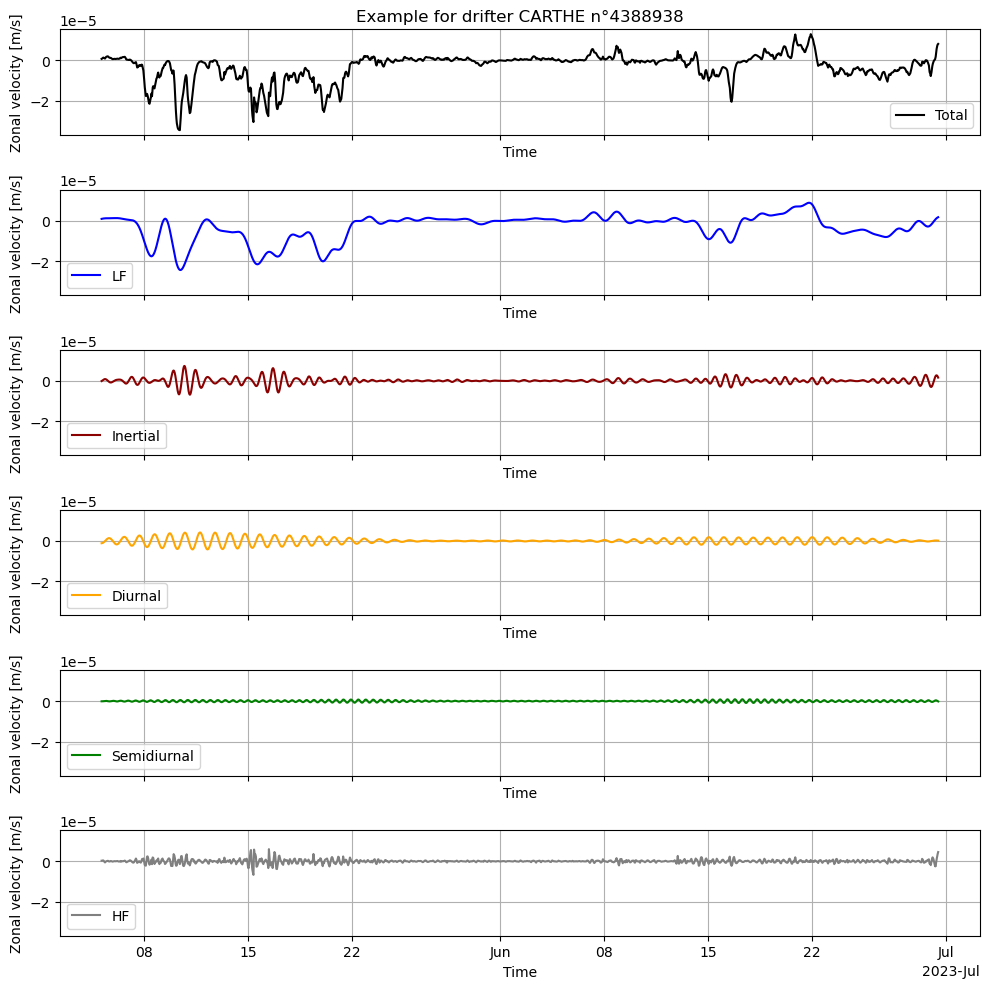

In [27]:
i=0
dsi_ = dsf.where(dsf.gap_mask ==1).sel(drifter_id ='4388938')

fig, axs= plt.subplots(6, 1, figsize=(10, 10), sharex=True, sharey=True, frameon=False)
ax = axs[0]
dsi_.vsde_rio_z0.plot(label='Total', ax=ax, c='k')
ax = axs[1]
dsi_.LFvsde_rio_z0.plot(label='LF', ax=ax, c='blue')
ax = axs[2]
dsi_.inertialvsde_rio_z0.plot(label='Inertial', ax=ax, c='darkred')
ax = axs[3]
dsi_.diurnalvsde_rio_z0.plot(label='Diurnal', ax=ax,c = 'orange')
ax = axs[4]
dsi_.semidiurnalvsde_rio_z0.plot(label='Semidiurnal', ax=ax, c = 'green')
ax = axs[5]
(dsi_.HFvsde_rio_z0).plot(label='HF', ax=ax,c = 'grey')
for ax in axs : 
    ax.grid()
    ax.legend()
    ax.set_title('')
    ax.set_ylabel('Zonal velocity [m/s]')
    ax.set_xlabel('Time')
axs[0].set_title(f'Example for drifter {dsi_.drifter_type.values} n°{dsi_.drifter_id.values}')
fig.tight_layout()
#fig.savefig(os.path.join(images_dir, 'spectral_decomp_zonal_velocities.png'))

In [30]:
cluster.close()

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask_jobqueue/core.py:237: FutureWarning: extra has been renamed to worker_extra_args. You are still using it (even if only set to []; please also check config files). If you did not set worker_extra_args yet, extra will be respected for now, but it will be removed in a future release. If you already set worker_extra_args, extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask_jobqueue/core.py:255: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/home1/datahome/mdemol/